#**Disease Outbreak Detection using Clustering**
TechCrush AI/ML Bootcamp Capstone Project

Group 28

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
import os
file=r"Disease Outbreak\climate_disease_dataset.csv"
print(os.path.exists(file))

True


In [3]:

df=pd.read_csv(file)
df.head()

,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34560 non-null  int64  
 1   month               34560 non-null  int64  
 2   country             34560 non-null  object 
 3   region              34560 non-null  object 
 4   avg_temp_c          34560 non-null  float64
 5   precipitation_mm    34560 non-null  float64
 6   air_quality_index   34560 non-null  float64
 7   uv_index            34560 non-null  float64
 8   malaria_cases       34560 non-null  int64  
 9   dengue_cases        34560 non-null  int64  
 10  population_density  34560 non-null  int64  
 11  healthcare_budget   34560 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 3.2+ MB


In [5]:
df.describe()

,year,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
count,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000
mean,2011.500000,6.500000,20.395234,192.667977,43.787766,10.210855,70.519560,75.941464,266.900000,2764.650000
std,6.922287,3.452102,8.410940,90.503990,33.079697,1.936540,46.130774,37.323807,136.001073,1418.119148
min,2000.000000,1.000000,-2.557056,0.000000,0.000000,0.870704,0.000000,0.000000,50.000000,205.000000
25%,2005.750000,3.750000,14.404089,124.641424,15.322767,8.921094,32.000000,48.000000,136.250000,1435.500000
50%,2011.500000,6.500000,20.351749,195.315309,40.685931,10.760990,69.000000,76.000000,277.500000,2859.000000
75%,2017.250000,9.250000,26.342978,260.147603,68.402041,12.000000,107.000000,104.000000,384.750000,3996.750000
max,2023.000000,12.000000,44.583564,485.704079,168.847690,12.000000,201.000000,181.000000,498.000000,4969.000000


In [6]:
df.isnull().sum()

year                  0
month                 0
country               0
region                0
avg_temp_c            0
precipitation_mm      0
air_quality_index     0
uv_index              0
malaria_cases         0
dengue_cases          0
population_density    0
healthcare_budget     0
dtype: int64

In [7]:
 #Total outbreak burden
df["total_cases"] = df["malaria_cases"] + df["dengue_cases"]

# Cyclical month encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [8]:
cluster_features = df[[
    'avg_temp_c',
    'precipitation_mm',
    'air_quality_index',
    'uv_index',
    'population_density',
    'healthcare_budget',
    'total_cases',
    'month_sin',
    'month_cos'
]]

Feature	Why it's useful	What it tells the model
avg_temp_c	Temperature affects the survival and spread of pathogens, insects, and vectors.	Whether the climate is favorable for disease transmission.
precipitation_mm	Rainfall influences water quality, flooding, mosquito breeding, and sanitation conditions.	Whether wet conditions may increase outbreak risk.
air_quality_index	Poor air quality can worsen respiratory illnesses and weaken population health.	The environmental health burden on a population.
uv_index	UV radiation can reduce the survival of some microorganisms outdoors.	Whether environmental conditions may naturally suppress or favor pathogens.
population_density	Diseases spread more easily where people live close together.	Potential transmission opportunity among people.
healthcare_budget	Represents healthcare capacity and preparedness.	Ability of a region to detect, manage, and contain outbreaks.
total_cases	Direct indicator of disease burden.	Current severity of disease activity.
month_sin	Captures seasonality in a continuous way.	Seasonal disease patterns without abrupt month changes.
month_cos	Works together with month_sin to encode cyclical time.

In [9]:
Scaler=StandardScaler()
X_scaled=Scaler.fit_transform(cluster_features)

In [10]:
print(X_scaled[:5])

[[ 9.19914533e-01 -4.48429882e-01  2.01635557e+00  9.23900367e-01
  -1.13162509e+00 -1.19642595e+00  7.92276131e-01  7.07106781e-01
   1.22474487e+00]
 [ 1.24735374e+00 -8.07451868e-01  1.19954957e+00  9.23900367e-01
  -1.13162509e+00 -1.19642595e+00  5.15573497e-01  1.22474487e+00
   7.07106781e-01]
 [ 1.30441522e+00 -1.06949155e+00  1.49058923e+00  9.23900367e-01
  -1.13162509e+00 -1.19642595e+00 -4.99002830e-01  1.41421356e+00
   1.52888398e-16]
 [ 9.61456493e-01 -1.91731843e-01  1.86650199e+00 -4.20839509e-01
  -1.13162509e+00 -1.19642595e+00  1.46636650e-01  1.22474487e+00
  -7.07106781e-01]
 [ 7.72235952e-01 -1.35022155e-02  4.96330147e-01 -1.42074526e-01
  -1.13162509e+00 -1.19642595e+00 -5.14375199e-01  7.07106781e-01
  -1.22474487e+00]]


PCA(Dimension Redundancy)

In [11]:
X_decomposed = PCA(n_components=2,random_state=42)
X_pca=X_decomposed.fit_transform(X_scaled)

In [12]:
print(X_pca[:15])

[[2.62535318 0.90643396]
 [2.47263877 0.13542547]
 [2.18683066 0.28192598]
 [2.18288444 0.94268343]
 [1.21472737 0.60540983]
 [1.51859348 1.61686278]
 [1.06798332 2.12787205]
 [1.17052942 2.50752282]
 [0.26254244 2.32431978]
 [0.69081787 2.62704198]
 [0.5701994  2.45136905]
 [1.5988117  1.45809753]
 [2.42948798 0.49472158]
 [3.22962    0.51164418]
 [2.59011169 0.45741327]]


In [13]:
print(X_pca[:15])

[[2.62535318 0.90643396]
 [2.47263877 0.13542547]
 [2.18683066 0.28192598]
 [2.18288444 0.94268343]
 [1.21472737 0.60540983]
 [1.51859348 1.61686278]
 [1.06798332 2.12787205]
 [1.17052942 2.50752282]
 [0.26254244 2.32431978]
 [0.69081787 2.62704198]
 [0.5701994  2.45136905]
 [1.5988117  1.45809753]
 [2.42948798 0.49472158]
 [3.22962    0.51164418]
 [2.59011169 0.45741327]]


In [14]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, labels)
    db_score = davies_bouldin_score(X_pca, labels)
    print(f"K={i}: Silhouette={silhouette_avg:.3f}, DB Score={db_score:.3f}")

K=2: Silhouette=0.353, DB Score=1.147
K=3: Silhouette=0.370, DB Score=0.877
K=4: Silhouette=0.366, DB Score=0.849
K=5: Silhouette=0.334, DB Score=0.933
K=6: Silhouette=0.348, DB Score=0.846
K=7: Silhouette=0.348, DB Score=0.812
K=8: Silhouette=0.340, DB Score=0.841
K=9: Silhouette=0.322, DB Score=0.892


In [15]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

for eps in [0.3, 0.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_pca)
    

    silhouette_avg = silhouette_score(X_pca, labels)
    db_score = davies_bouldin_score(X_pca, labels)
    print(f"DBSCAN eps={eps}: Silhouette={silhouette_avg:.3f}, DB Score={db_score:.3f}")
    

DBSCAN eps=0.3: Silhouette=0.435, DB Score=2.017
DBSCAN eps=0.5: Silhouette=0.417, DB Score=0.489


In [16]:
#Gaussian Mixture Model
for i in range(2, 10):
     gmm = GaussianMixture(n_components=i, covariance_type='full', random_state=42)
     gmm.fit(X_pca)
     labels = gmm.predict(X_pca)
     silhouette_avg = silhouette_score(X_pca, labels)
     db_score = davies_bouldin_score(X_pca, labels)
     print(f"GMM K={i}: Silhouette={silhouette_avg:.3f}, DB Score={db_score:.3f}")


GMM K=2: Silhouette=0.350, DB Score=1.169
GMM K=3: Silhouette=0.358, DB Score=0.879
GMM K=4: Silhouette=0.364, DB Score=0.848
GMM K=5: Silhouette=0.333, DB Score=0.951
GMM K=6: Silhouette=0.344, DB Score=0.832
GMM K=7: Silhouette=0.346, DB Score=0.821
GMM K=8: Silhouette=0.339, DB Score=0.838
GMM K=9: Silhouette=0.317, DB Score=0.886


In [17]:
score = silhouette_score(X_pca, labels)
db_score = davies_bouldin_score(X_pca, labels)
print("Silhouette Score (GMM):", score)
print("Davies-Bouldin Score (GMM):", db_score)

Silhouette Score (GMM): 0.3168876888807228
Davies-Bouldin Score (GMM): 0.8859638801642367


In [18]:
k_range = range(2, 11)

wcss = []
silhouette_scores_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, labels))

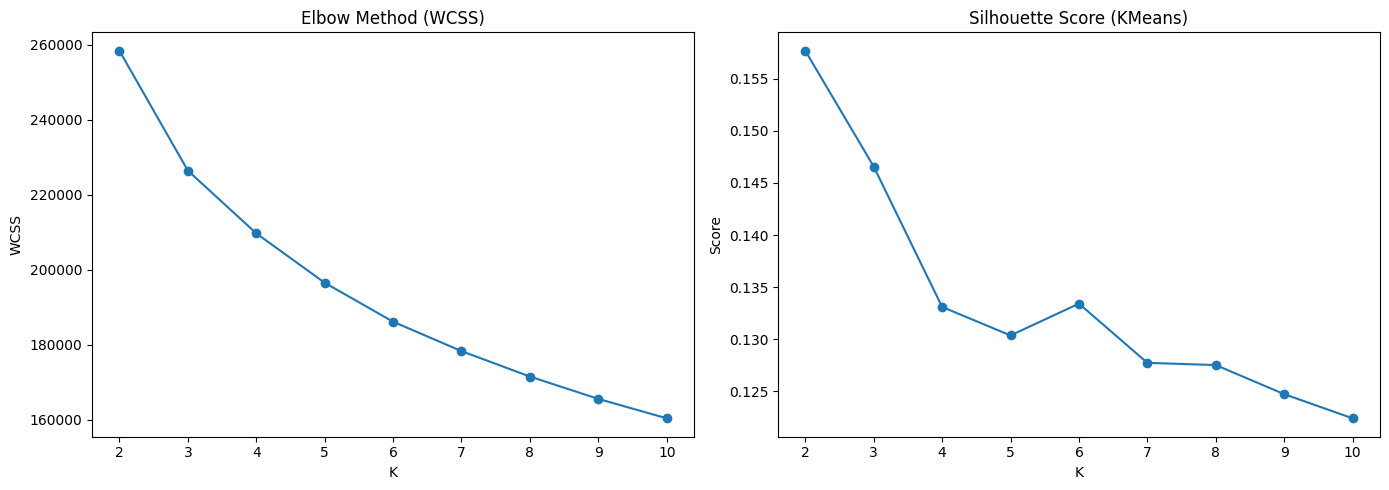

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title("Elbow Method (WCSS)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("WCSS")

axes[1].plot(k_range, silhouette_scores_kmeans, marker='o')
axes[1].set_title("Silhouette Score (KMeans)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [20]:
best_k_kmeans = k_range[np.argmax(silhouette_scores_kmeans)]
print("Best KMeans K:", best_k_kmeans)

Best KMeans K: 2


In [21]:
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

In [22]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = db_labels

# Check cluster distribution
print("DBSCAN clusters:", np.unique(db_labels, return_counts=True))

DBSCAN clusters: (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]), array([34206,     5,    10,     5,     6,     5,     5,     5,     5,
           5,     5,     5,     5,     5,     9,     5,     5,     6,
           6,     7,     5,     5,     6,     5,     6,     5,     8,
           7,     5,     5,     5,     6,     7,     5,     6,     4,
           7,     5,     5,     5,     5,     5,     5,     6,     5,
           5,     5,     5,     6,     5,     5,    12,     8,     7,
           6,     5,     6,     5,     6,     5,     5,     6,     5]))


In [23]:
if len(set(db_labels)) > 1 and len(set(db_labels)) > 2:
    sil_dbscan = silhouette_score(X_scaled, db_labels)
    db_dbscan = davies_bouldin_score(X_scaled, db_labels)

    print("DBSCAN Silhouette:", sil_dbscan)
    print("DBSCAN DB Index:", db_dbscan)
else:
    print("DBSCAN: Not enough clusters for reliable evaluation")

DBSCAN Silhouette: -0.48095331583939993
DBSCAN DB Index: 1.1796405491147766


In [24]:
gmm_range = range(2, 11)

silhouette_scores_gmm = []

for k in gmm_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)

    labels = gmm.predict(X_scaled)

    silhouette_scores_gmm.append(silhouette_score(X_scaled, labels))

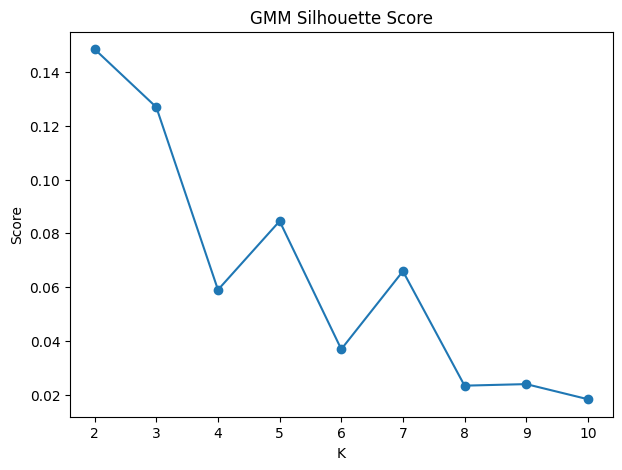

In [25]:
plt.figure(figsize=(7,5))
plt.plot(gmm_range, silhouette_scores_gmm, marker='o')
plt.title("GMM Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

In [26]:
best_k_gmm = gmm_range[np.argmax(silhouette_scores_gmm)]
print("Best GMM K:", best_k_gmm)

Best GMM K: 2


In [27]:
gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
df["gmm_cluster"] = gmm.fit_predict(X_scaled)

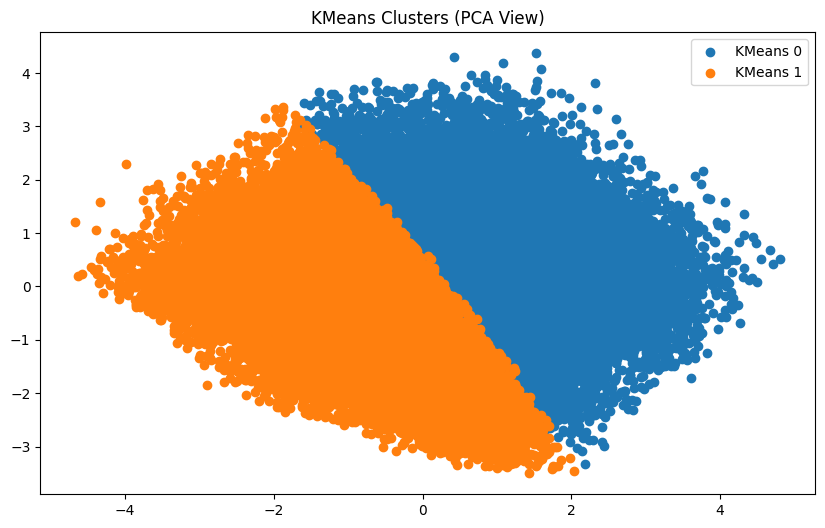

In [28]:
plt.figure(figsize=(10,6))

for i in range(best_k_kmeans):
    plt.scatter(
        X_pca[df["kmeans_cluster"] == i, 0],
        X_pca[df["kmeans_cluster"] == i, 1],
        label=f"KMeans {i}"
    )

plt.title("KMeans Clusters (PCA View)")
plt.legend()
plt.show()

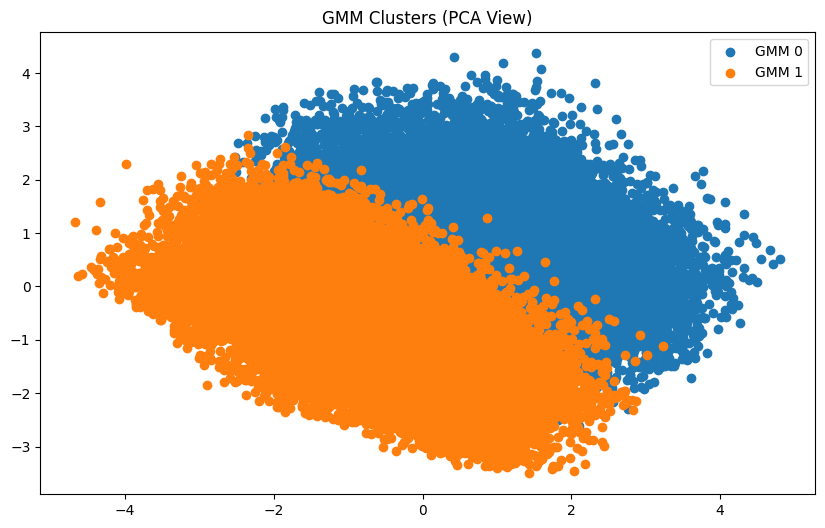

In [29]:
plt.figure(figsize=(10,6))

for i in range(best_k_gmm):
    plt.scatter(
        X_pca[df["gmm_cluster"] == i, 0],
        X_pca[df["gmm_cluster"] == i, 1],
        label=f"GMM {i}"
    )

plt.title("GMM Clusters (PCA View)")
plt.legend()
plt.show()

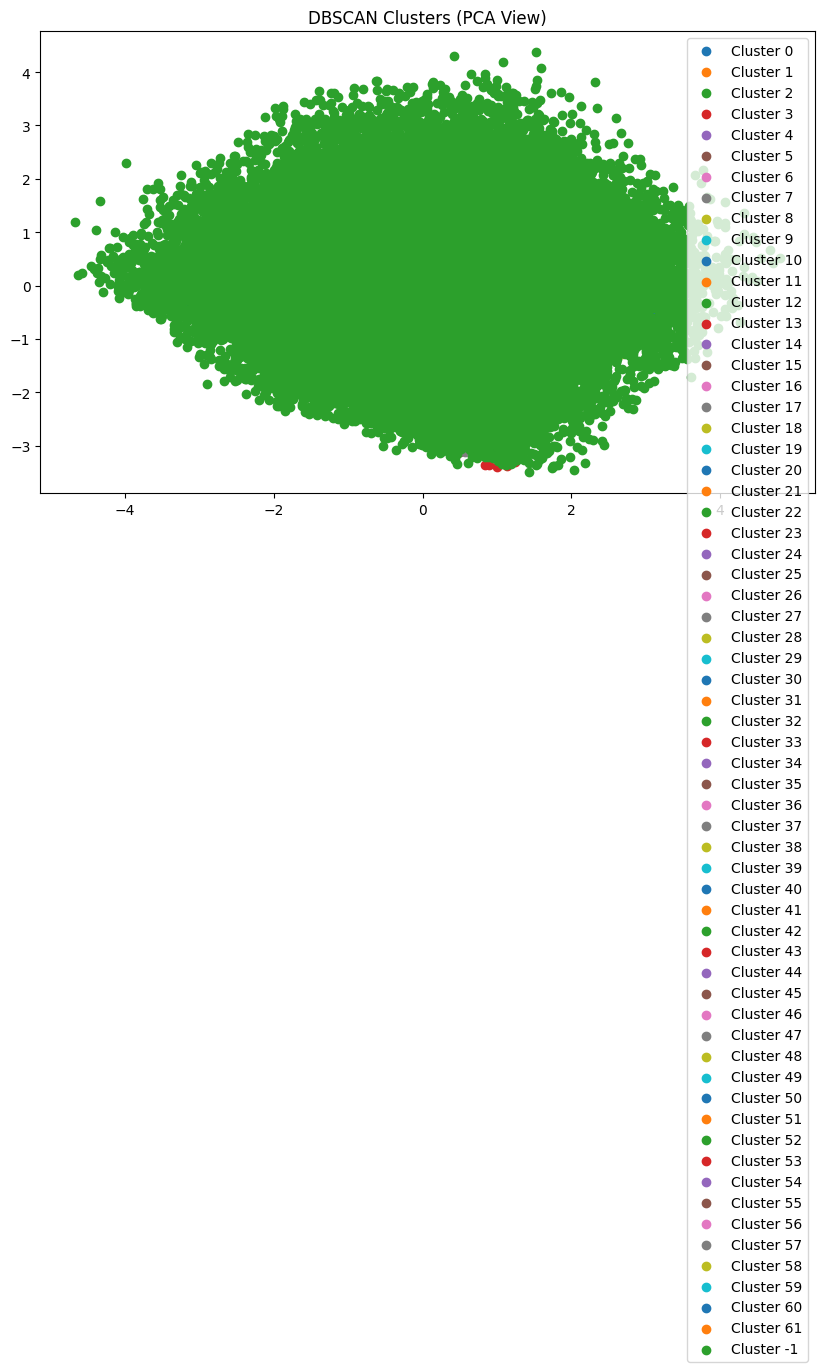

In [30]:
plt.figure(figsize=(10,6))

unique_labels = set(db_labels)

for i in unique_labels:
    plt.scatter(
        X_pca[df["dbscan_cluster"] == i, 0],
        X_pca[df["dbscan_cluster"] == i, 1],
        label=f"Cluster {i}"
    )

plt.title("DBSCAN Clusters (PCA View)")
plt.legend()
plt.show()

In [31]:
cluster_risk = df.groupby("gmm_cluster")["total_cases"].mean().sort_values()

In [36]:
print(cluster_risk)

gmm_cluster
1    132.828625
0    163.197048
Name: total_cases, dtype: float64


In [32]:
risk_map = {
    cluster_risk.index[0]: "Low Risk",
    cluster_risk.index[1]: "High Risk"
}

df["risk_level"] = df["gmm_cluster"].map(risk_map)

The Gaussian Mixture Model identified two distinct outbreak-risk profiles. Cluster 0 was characterized by higher rainfall, poorer air quality, lower healthcare budgets, and substantially higher malaria and dengue case counts. This cluster represents high-risk outbreak regions. Cluster 1 exhibited lower disease incidence despite having higher population density, which coincided with significantly greater healthcare investment. These findings suggest that healthcare capacity may play a critical role in mitigating disease outbreaks even in densely populated environments.


In [33]:
df["gmm_cluster"].value_counts()

gmm_cluster
1    19046
0    15514
Name: count, dtype: int64

In [42]:
risk_score = (
    df.groupby("gmm_cluster")["air_quality_index"].mean() +
    df.groupby("gmm_cluster")["population_density"].mean() +
    df.groupby("gmm_cluster")["total_cases"].mean()
)

In [41]:

import joblib

joblib.dump(X_decomposed, "Climate_Diseases_pca.pkl")
joblib.dump(Scaler, "Climate_Diseases_scaler.pkl")
joblib.dump(X_decomposed , "Climate_Diseases_pca.pkl")
joblib.dump(kmeans, "Climate_Diseases_kmeans.pkl")
joblib.dump(gmm, "Climate_Diseases_model.pkl")

['Climate_Diseases_model.pkl']